In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (11, 6)

# Load
df = pd.read_csv("FDA_Nutrients.csv")

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nHead:\n", df.head(3))
print("\nInfo:")
print(df.info())


Shape: (2970, 14)

Columns: ['Protein', 'Total Fat', 'Carbohydrate', 'Sugars, total', 'Fiber, total dietary', 'Calcium', 'Iron', 'Sodium', 'Vitamin D (D2 + D3)', 'Cholesterol', 'Fatty acids, total saturated', 'Potassium', 'Energy', 'novaclass']

Head:
    Protein  Total Fat  Carbohydrate  Sugars, total  Fiber, total dietary  \
0     1.03       4.38          6.89           6.89                   0.0   
1     3.28       1.91          4.85           5.08                   0.0   
2     3.15       3.25          4.80           5.05                   0.0   

   Calcium  Iron  Sodium  Vitamin D (D2 + D3)  Cholesterol  \
0     32.0  0.03    17.0                  0.1         14.0   
1    119.0  0.03    44.0                  1.2          7.0   
2    113.0  0.03    43.0                  1.3         10.0   

   Fatty acids, total saturated  Potassium  Energy  novaclass  
0                         2.009       51.0    70.0          1  
1                         1.154      142.0    50.0          1  
2

In [3]:
df.head()

,Protein,Total Fat,Carbohydrate,"Sugars, total","Fiber, total dietary",Calcium,Iron,Sodium,Vitamin D (D2 + D3),Cholesterol,"Fatty acids, total saturated",Potassium,Energy,novaclass
0,1.03,4.38,6.89,6.89,0.0,32.0,0.03,17.0,0.1,14.0,2.009,51.0,70.0,1
1,3.28,1.91,4.85,5.08,0.0,119.0,0.03,44.0,1.2,7.0,1.154,142.0,50.0,1
2,3.15,3.25,4.80,5.05,0.0,113.0,0.03,43.0,1.3,10.0,1.865,132.0,61.0,1
3,3.10,3.46,4.46,4.46,0.0,101.0,0.05,3.0,1.3,14.0,2.154,253.0,61.0,1
4,3.14,3.24,4.79,5.04,0.0,412.0,0.03,43.0,1.3,10.0,1.859,132.0,61.0,1


In [4]:
# Copy and clean column names
df = df.copy()
df.columns = (
    df.columns.str.strip()
              .str.replace(r'\\s+', '_', regex=True)
              .str.replace(r'[^0-9A-Za-z_]+', '', regex=True)
)

# Ensure numeric types
num_cols = [c for c in df.columns if c != "novaclass"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

# Basic integrity checks
assert "novaclass" in df.columns, "novaclass column missing"

print("After cleaning dtypes:\n", df.dtypes.value_counts())


After cleaning dtypes:
 float64    13
int64       1
Name: count, dtype: int64


In [5]:
# Missing summary
na = df.isna().sum().sort_values(ascending=False)
na_pct = (na/len(df)*100).round(2)
missing_df = pd.DataFrame({"missing": na, "missing_pct": na_pct})
print("\nMissing values:\n", missing_df[missing_df.missing>0])

# Duplicates
dup_count = df.duplicated().sum()
print(f"\nDuplicate rows: {dup_count}")



Missing values:
 Empty DataFrame
Columns: [missing, missing_pct]
Index: []

Duplicate rows: 393


In [6]:
# Overall numeric summary
desc = df[num_cols].describe().T
desc["skew"] = df[num_cols].skew(numeric_only=True)
desc["kurtosis"] = df[num_cols].kurt(numeric_only=True)
print("\nOverall summary with skew/kurtosis:\n", desc)

# Class distribution
print("\nnovaclass distribution:\n", df["novaclass"].value_counts(dropna=False).sort_index())

# Per-class summary (means)
per_class_mean = df.groupby("novaclass")[num_cols].mean().round(3)
print("\nPer-class mean:\n", per_class_mean.head())

# Export for report
desc.to_csv("fda_overall_summary.csv")
per_class_mean.to_csv("fda_per_class_means.csv")



Overall summary with skew/kurtosis:
                            count        mean         std  min       25%  \
Protein                   2970.0    6.709074    7.552930  0.0   1.20000   
TotalFat                  2970.0    9.877902   15.170097  0.0   0.50000   
Carbohydrate              2970.0   30.716303   28.530265  0.0   6.95250   
Sugarstotal               2970.0   13.723811   17.778250  0.0   1.55000   
Fibertotaldietary         2970.0    2.291212    3.916912  0.0   0.00000   
Calcium                   2970.0   93.794949  189.380876  0.0  11.25000   
Iron                      2970.0    2.764064    6.313006  0.0   0.29250   
Sodium                    2970.0  357.308418  814.596344  0.0  21.00000   
VitaminDD2D3              2970.0    0.488316    1.605750  0.0   0.00000   
Cholesterol               2970.0   16.367677   46.330706  0.0   0.00000   
Fattyacidstotalsaturated  2970.0    3.209539    5.502875  0.0   0.09425   
Potassium                 2970.0  220.959933  297.763523  0.0 

In [7]:
def iqr_outlier_mask(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    return (s < low) | (s > high)

outlier_report = []
for c in num_cols:
    s = df[c].dropna()
    if s.empty:
        continue
    mask = iqr_outlier_mask(s)
    outlier_report.append({
        "feature": c,
        "outlier_count": mask.sum(),
        "outlier_pct": (mask.mean()*100).round(2)
    })

outlier_df = pd.DataFrame(outlier_report).sort_values("outlier_pct", ascending=False)
print("\nOutlier percentages:\n", outlier_df.head(15))
outlier_df.to_csv("fda_outliers_iqr.csv", index=False)



Outlier percentages:
                      feature  outlier_count  outlier_pct
8               VitaminDD2D3            598        20.13
9                Cholesterol            461        15.52
10  Fattyacidstotalsaturated            291         9.80
6                       Iron            249         8.38
4          Fibertotaldietary            248         8.35
5                    Calcium            242         8.15
11                 Potassium            216         7.27
3                Sugarstotal            198         6.67
1                   TotalFat            174         5.86
0                    Protein            152         5.12
7                     Sodium            104         3.50
12                    Energy             22         0.74
2               Carbohydrate              0         0.00


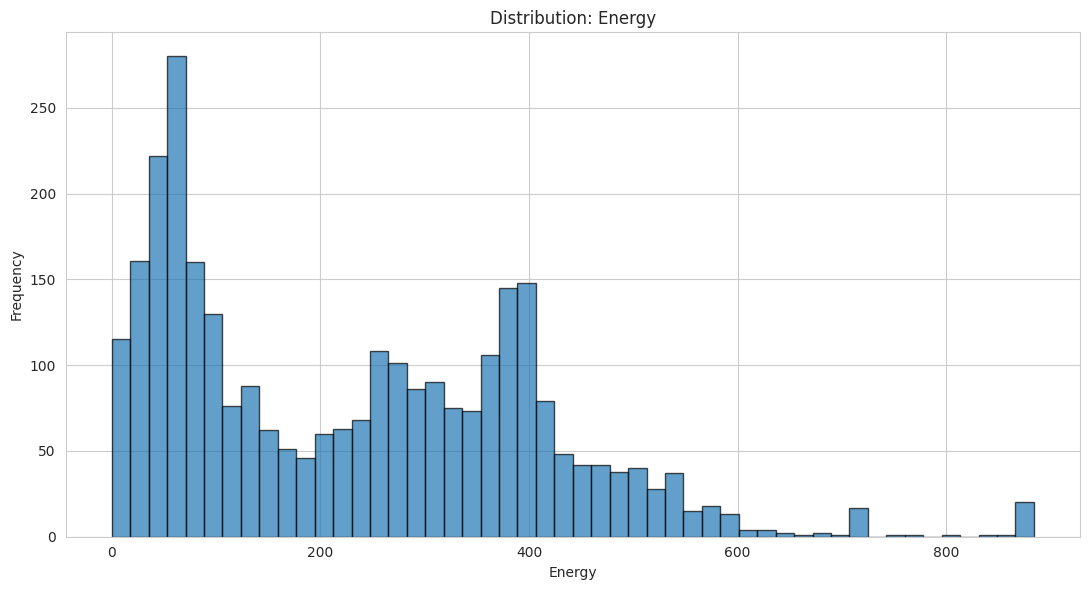

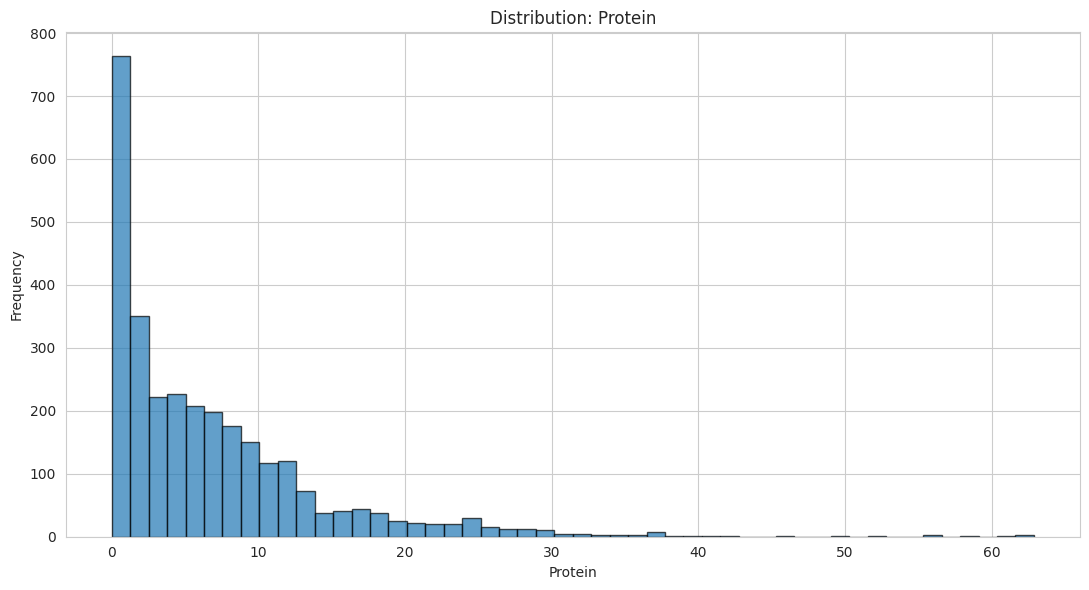

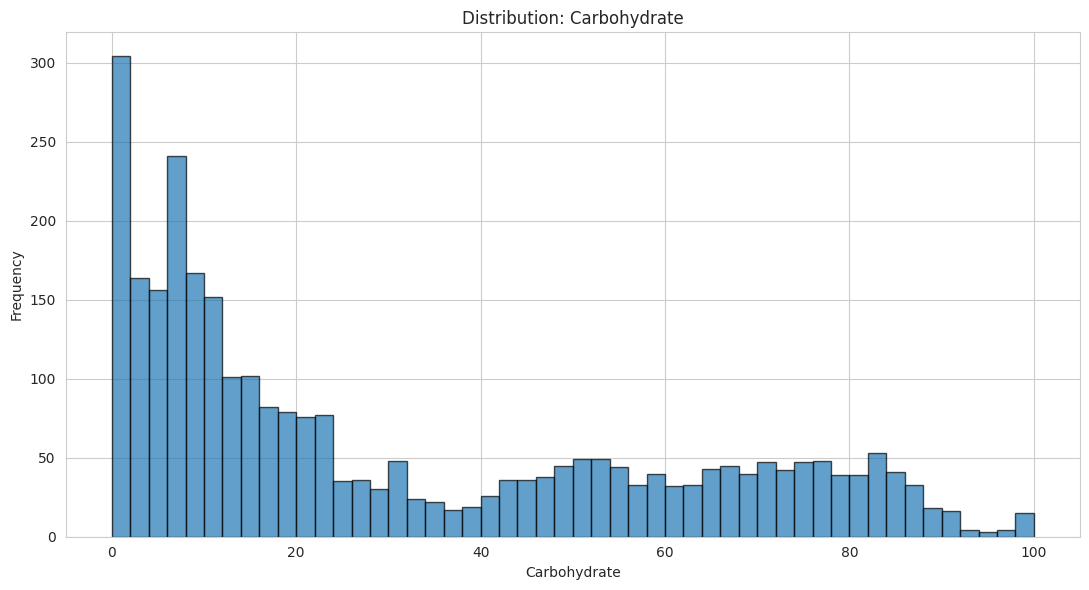

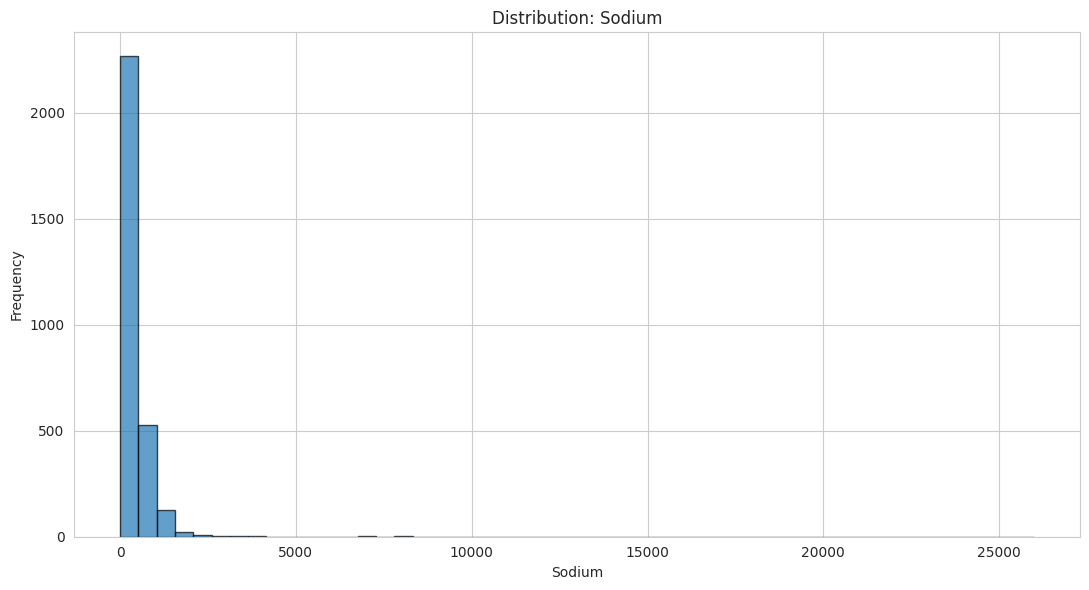

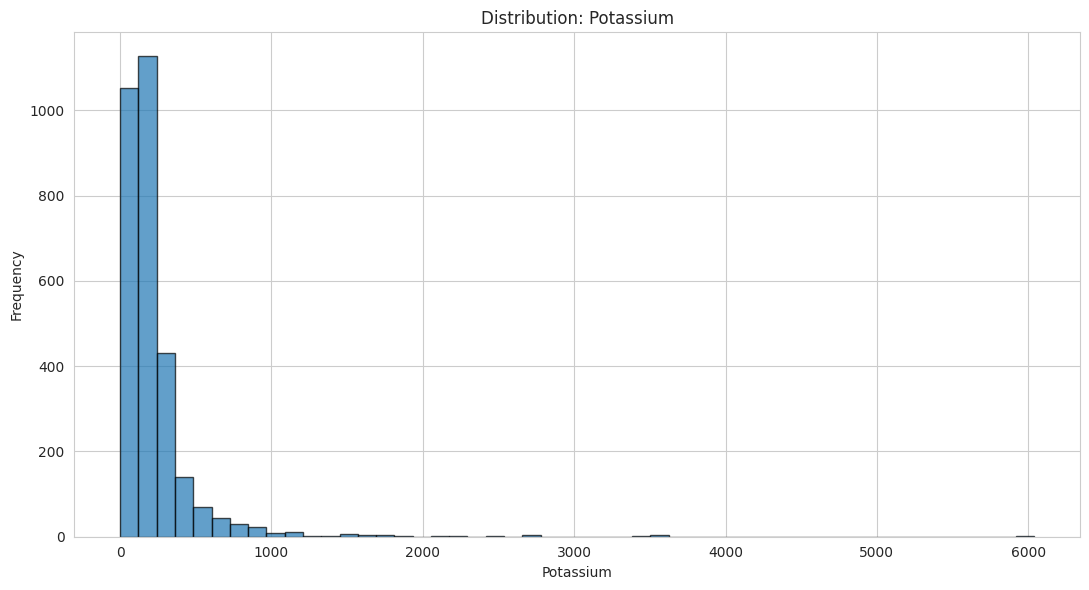

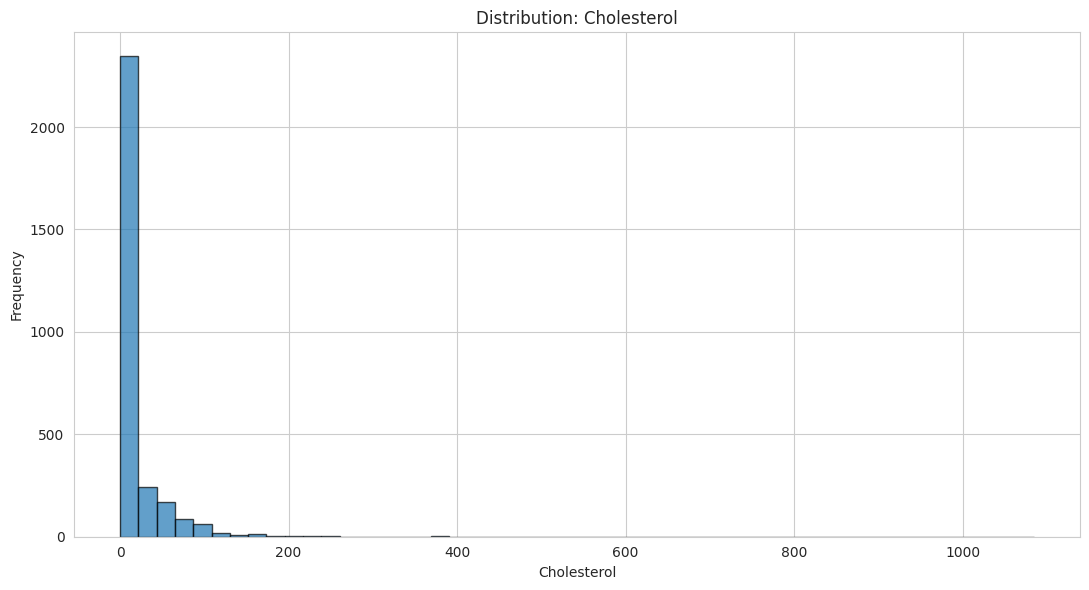

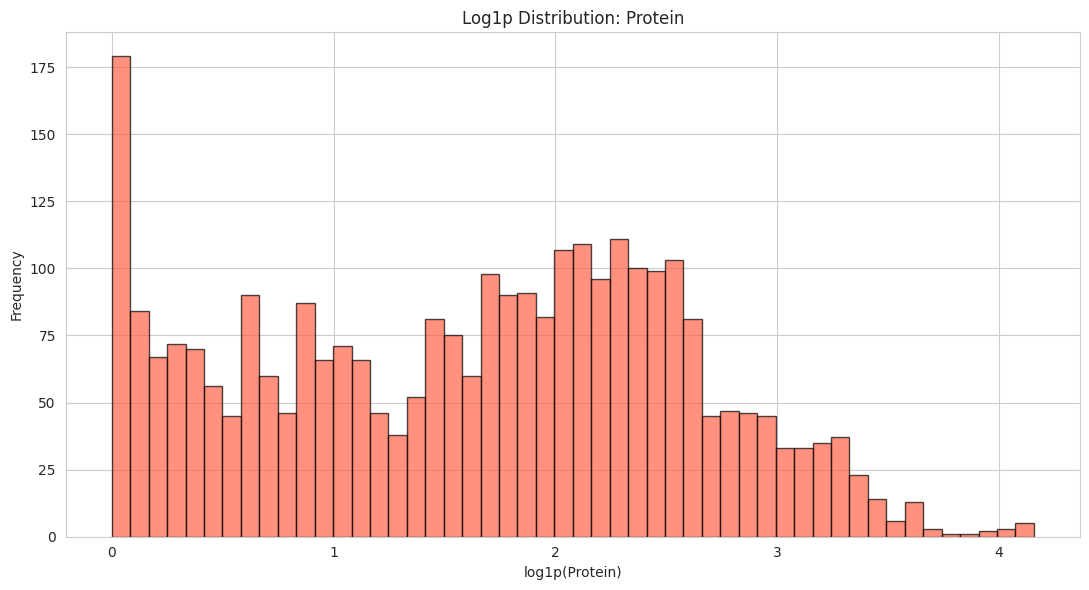

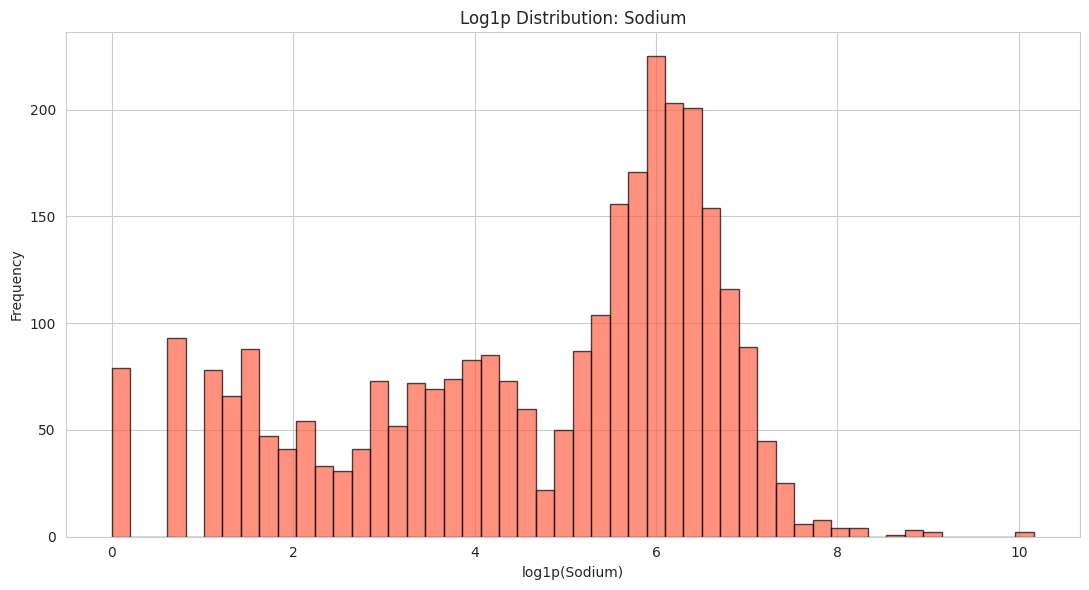

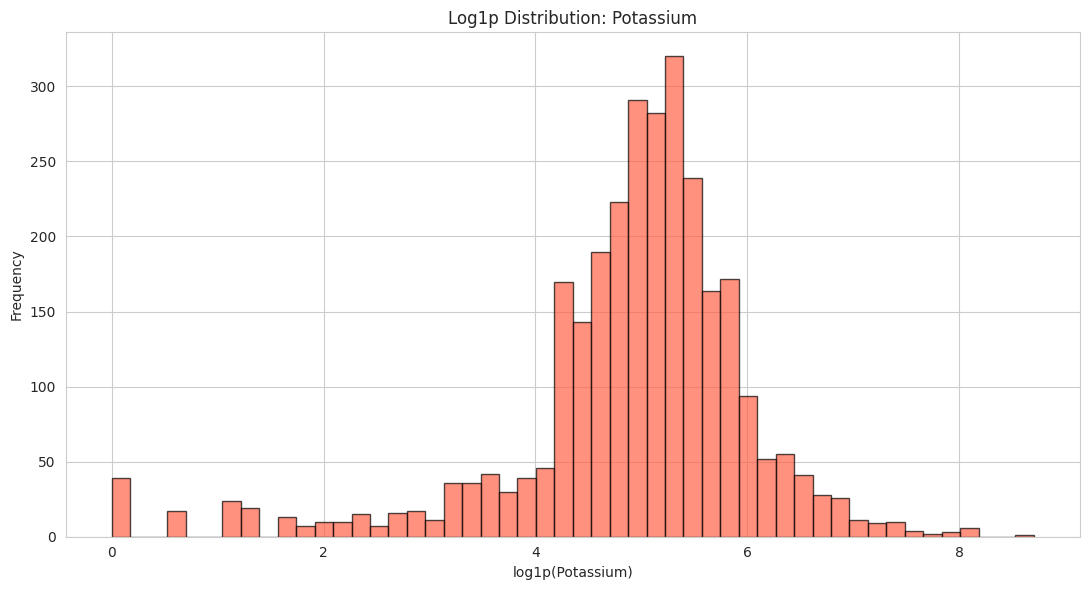

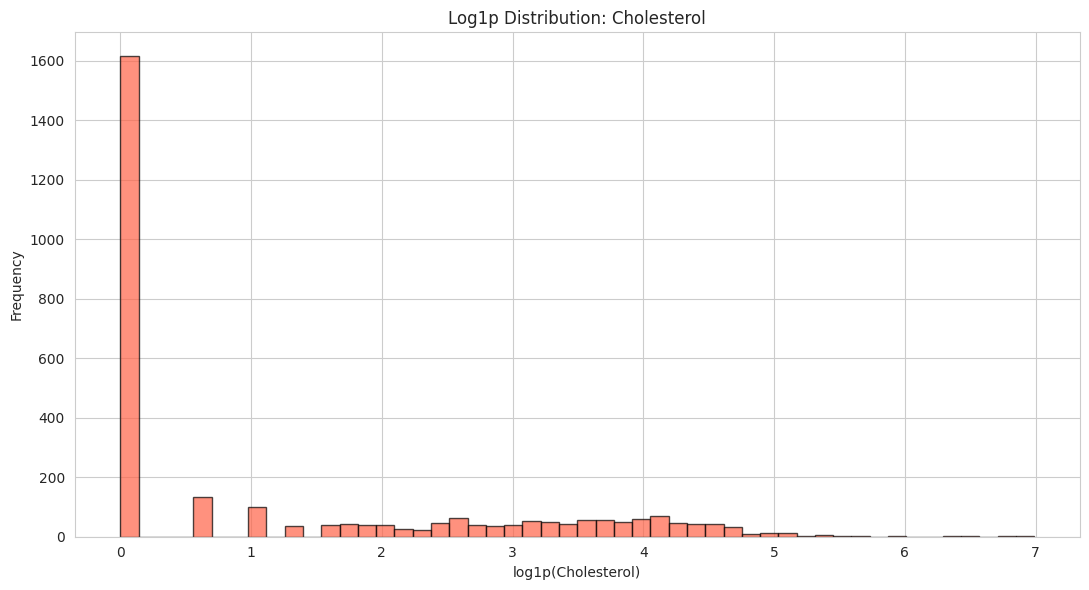

In [8]:
key_feats = [
    "Energy", "Protein", "Total_Fat", "Carbohydrate",
    "Sugars_total", "Fiber_total_dietary",
    "Sodium", "Potassium", "Cholesterol", "Fatty_acids_total_saturated"
]
key_feats = [c for c in key_feats if c in df.columns]

for c in key_feats:
    ax = df[c].plot(kind="hist", bins=50, alpha=0.7, edgecolor="black")
    ax.set_title(f"Distribution: {c}")
    ax.set_xlabel(c)
    plt.tight_layout()
    plt.show()

# Log-scale alternative for skewed features
skewed = [c for c in key_feats if df[c].dropna().skew() > 2]
for c in skewed:
    ax = np.log1p(df[c]).plot(kind="hist", bins=50, alpha=0.7, edgecolor="black", color="tomato")
    ax.set_title(f"Log1p Distribution: {c}")
    ax.set_xlabel(f"log1p({c})")
    plt.tight_layout()
    plt.show()


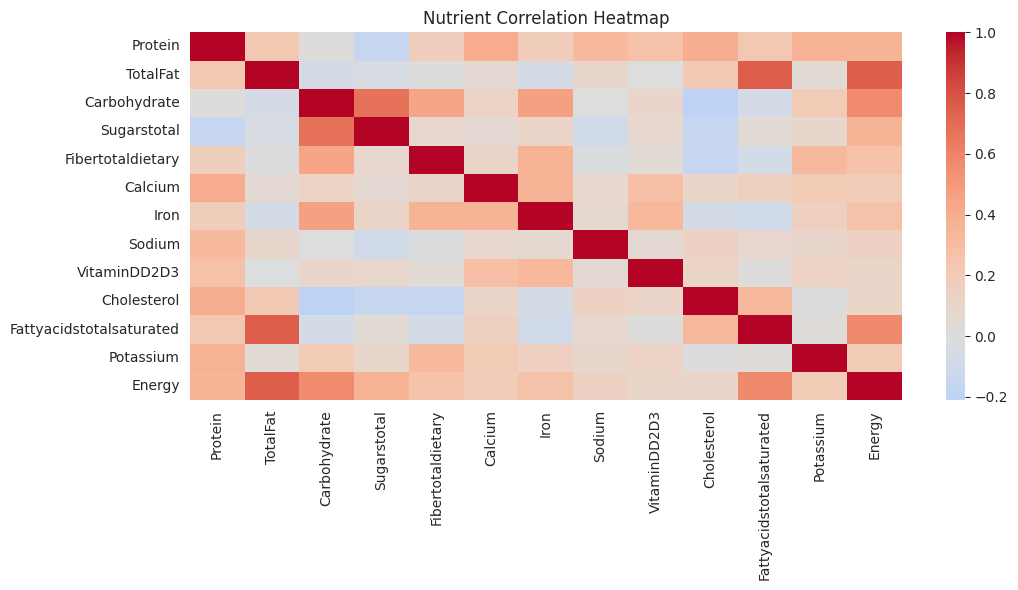


Highly correlated pairs (|r| >= 0.9):


In [9]:
corr = df[num_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Nutrient Correlation Heatmap")
plt.tight_layout()
plt.show()

# List highly correlated pairs
pairs = []
thr = 0.9
for i, a in enumerate(num_cols):
    for b in num_cols[i+1:]:
        r = corr.loc[a, b]
        if pd.notna(r) and abs(r) >= thr:
            pairs.append((a, b, r))
pairs_sorted = sorted(pairs, key=lambda x: -abs(x[2]))
print("\nHighly correlated pairs (|r| >= 0.9):")
for a, b, r in pairs_sorted[:20]:
    print(f"{a} ~ {b}: r={r:.3f}")


In [10]:
df_feat = df.copy()

# Common ratios/densities
eps = 1e-6
if {"Protein","Carbohydrate","Total_Fat"}.issubset(df.columns):
    df_feat["protein_carb_ratio"] = df_feat["Protein"] / (df_feat["Carbohydrate"] + eps)
    df_feat["fat_carb_ratio"] = df_feat["Total_Fat"] / (df_feat["Carbohydrate"] + eps)
    df_feat["fat_protein_ratio"] = df_feat["Total_Fat"] / (df_feat["Protein"] + eps)

# Sodium-Potassium balance
if {"Sodium","Potassium"}.issubset(df.columns):
    df_feat["na_k_ratio"] = df_feat["Sodium"] / (df_feat["Potassium"] + eps)

# Sugar to carb fraction
if {"Sugars_total","Carbohydrate"}.issubset(df.columns):
    df_feat["sugar_carb_frac"] = df_feat["Sugars_total"] / (df_feat["Carbohydrate"] + eps)

# Fiber to carb fraction
if {"Fiber_total_dietary","Carbohydrate"}.issubset(df.columns):
    df_feat["fiber_carb_frac"] = df_feat["Fiber_total_dietary"] / (df_feat["Carbohydrate"] + eps)

ratio_cols = [c for c in df_feat.columns if c not in df.columns and c != "novaclass"]
print("\nCreated ratio features:", ratio_cols)

print("\nRatio feature summary:\n", df_feat[ratio_cols].describe().T)



Created ratio features: ['na_k_ratio']

Ratio feature summary:
              count          mean           std  min       25%       50%  \
na_k_ratio  2970.0  79801.626013  2.394707e+06  0.0  0.239622  1.092096   

                 75%          max  
na_k_ratio  3.306038  125000000.0  


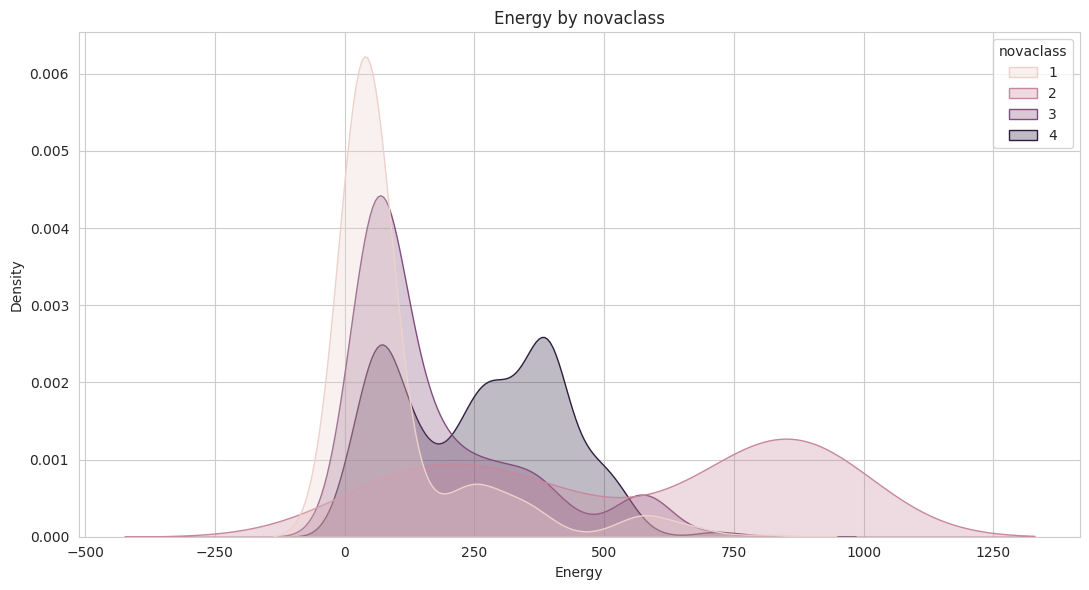

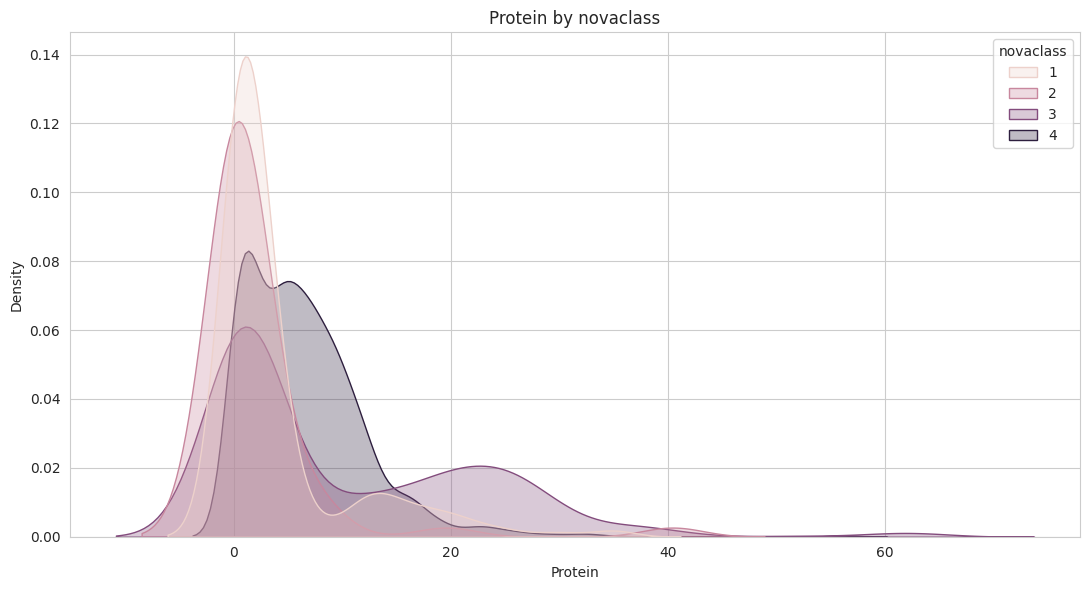

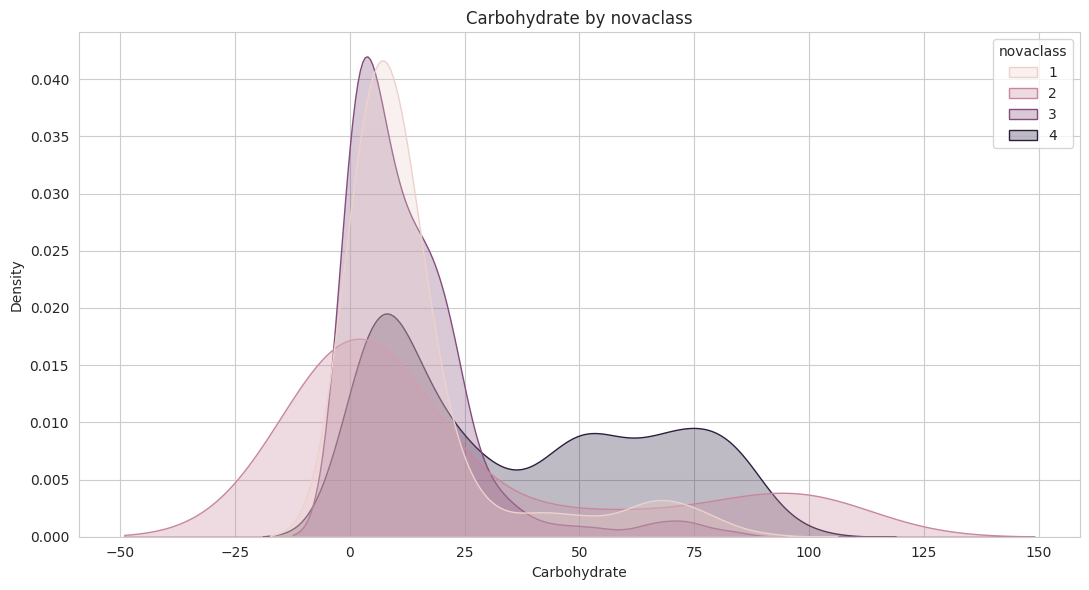

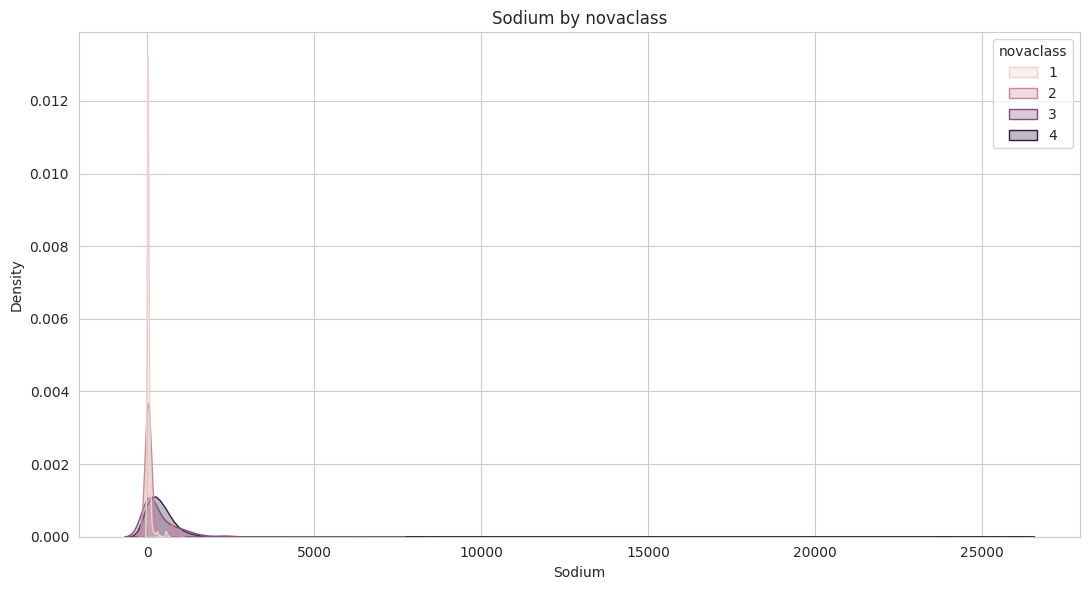

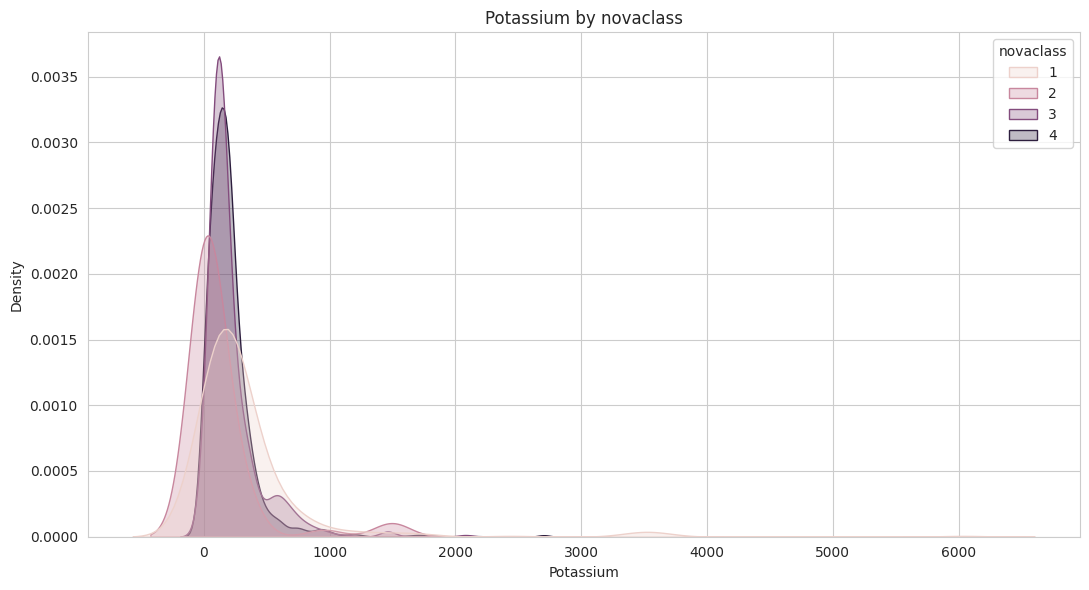

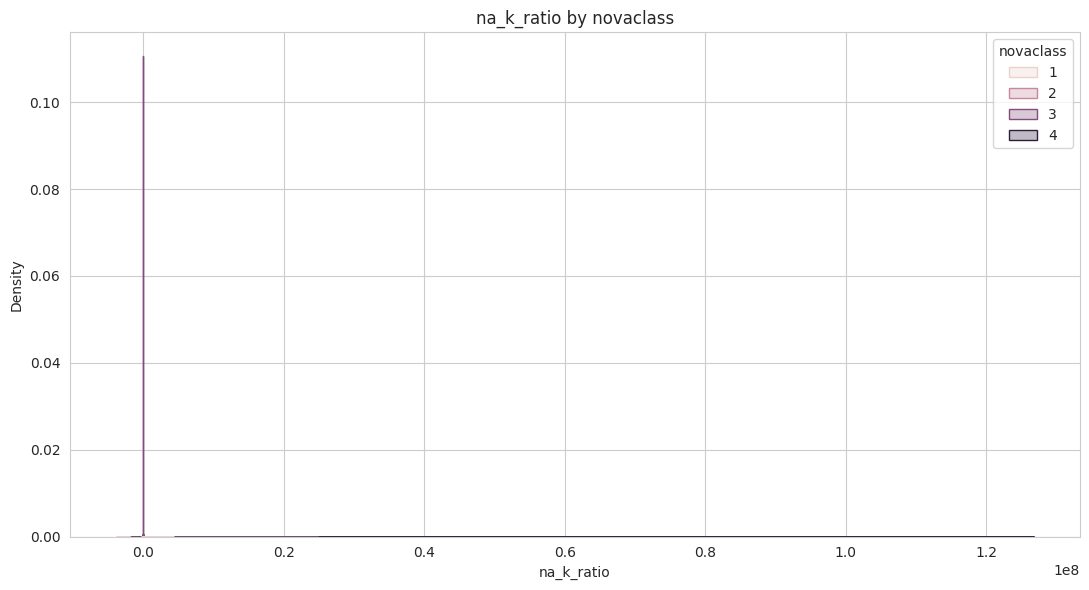


Top class-separating features by ANOVA F-stat:
         feature      F_stat
0        Energy  180.708468
2  Carbohydrate  160.641277
1       Protein   59.222647
3        Sodium   24.089215
4     Potassium   23.845619
5    na_k_ratio    0.554168


In [11]:
cand = ["Energy","Protein","Total_Fat","Carbohydrate","Sugars_total",
        "Fiber_total_dietary","Sodium","Potassium","na_k_ratio","sugar_carb_frac","fiber_carb_frac"]
cand = [c for c in cand if c in df_feat.columns]

for c in cand:
    sns.kdeplot(data=df_feat, x=c, hue="novaclass", common_norm=False, fill=True, alpha=0.3)
    plt.title(f"{c} by novaclass")
    plt.tight_layout()
    plt.show()

# ANOVA-style screening
anova_rows = []
for c in cand:
    groups = [g.dropna().values for _, g in df_feat.groupby("novaclass")[c]]
    if len(groups) >= 2 and all(len(g) > 1 for g in groups):
        f = stats.f_oneway(*groups)[0]
        anova_rows.append((c, f))
anova_df = pd.DataFrame(anova_rows, columns=["feature","F_stat"]).sort_values("F_stat", ascending=False)
print("\nTop class-separating features by ANOVA F-stat:\n", anova_df.head(10))
anova_df.to_csv("fda_class_separability.csv", index=False)


In [13]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
scaled = scaler.fit_transform(df[num_cols].fillna(df[num_cols].median()))
scaled_df = pd.DataFrame(scaled, columns=num_cols)

print("\nScaled preview (median ~ 0, IQR ~ 1):")
print(scaled_df.describe().T.head(10))



Scaled preview (median ~ 0, IQR ~ 1):
                    count      mean       std       min       25%  \
Protein            2970.0  0.260129  0.909992 -0.548193 -0.403614   
TotalFat           2970.0  0.479611  1.158023 -0.274427 -0.236260   
Carbohydrate       2970.0  0.258438  0.595280 -0.382453 -0.237390   
Sugarstotal        2970.0  0.401745  0.975219 -0.351070 -0.266045   
Fibertotaldietary  2970.0  0.389719  1.398897 -0.428571 -0.428571   
Calcium            2970.0  0.639943  2.133869 -0.416901 -0.290141   
Iron               2970.0  0.818484  2.912575 -0.456747 -0.321799   
Sodium             2970.0  0.301270  1.700619 -0.444676 -0.400835   
VitaminDD2D3       2970.0  2.441582  8.028748  0.000000  0.000000   
Cholesterol        2970.0  1.169120  3.309336  0.000000  0.000000   

                            50%       75%         max  
Protein            0.000000e+00  0.596386    7.027711  
TotalFat           1.696776e-17  0.763740    7.359160  
Carbohydrate       3.707971e-17  

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer

X = df_feat.drop(columns=["novaclass"])
y = df_feat["novaclass"]

imp = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imp.fit_transform(X), columns=X.columns)

Xtr, Xte, ytr, yte = train_test_split(X_imp, y, test_size=0.2, stratify=y, random_state=42)

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced")
rf.fit(Xtr, ytr)
print("\nBaseline RF report:\n", classification_report(yte, rf.predict(Xte)))

fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 15 feature importances:\n", fi.head(15))
fi.head(50).to_csv("fda_feature_importance_rf.csv")



Baseline RF report:
               precision    recall  f1-score   support

           1       0.84      0.71      0.77        68
           2       0.90      0.82      0.86        11
           3       0.83      0.69      0.75        93
           4       0.92      0.98      0.95       422

    accuracy                           0.90       594
   macro avg       0.87      0.80      0.83       594
weighted avg       0.90      0.90      0.90       594


Top 15 feature importances:
 na_k_ratio                  0.109384
Energy                      0.107999
Protein                     0.107035
Potassium                   0.092706
TotalFat                    0.090873
Carbohydrate                0.082732
Sodium                      0.080561
Fattyacidstotalsaturated    0.066627
Fibertotaldietary           0.059454
Sugarstotal                 0.058916
Iron                        0.055661
Calcium                     0.049370
Cholesterol                 0.023939
VitaminDD2D3                0.01

In [15]:
# Correlation CSV
df[num_cols].corr().to_csv("fda_correlations.csv")

# Export enhanced dataset with ratio features (optional)
df_feat.to_csv("FDA_Nutrients_enriched.csv", index=False)
